# Pandas 실습 2

### 1. 데이터 준비
- 서울시 공공자전거(따릉이) 대여 데이터

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

In [24]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# 데이터 로드
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수.csv')
df1.head()

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354


In [8]:
# 데이터 로드
df2 = pd.read_excel('data/대여소별 반납내역(2017년).xlsx')
df2.head()

,대여소 그룹,대여소 명,반납 일자 / 월,반납 건수
0,그룹명 없음,대여소명 없음,2017-01-01,10
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,12
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,13
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,8


In [11]:
# df1의 일자별 대여건수 top10
df1['대여일자'].value_counts()
df1['대여일자'].dtypes

dtype('O')

In [18]:
# '대여일자' 데이터 타입 변환, to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [22]:
# df1의 2025년도 월별 대여건수
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals.index
df1_rentals.values

array([217, 248, 270, 310, 330, 372], dtype=int32)

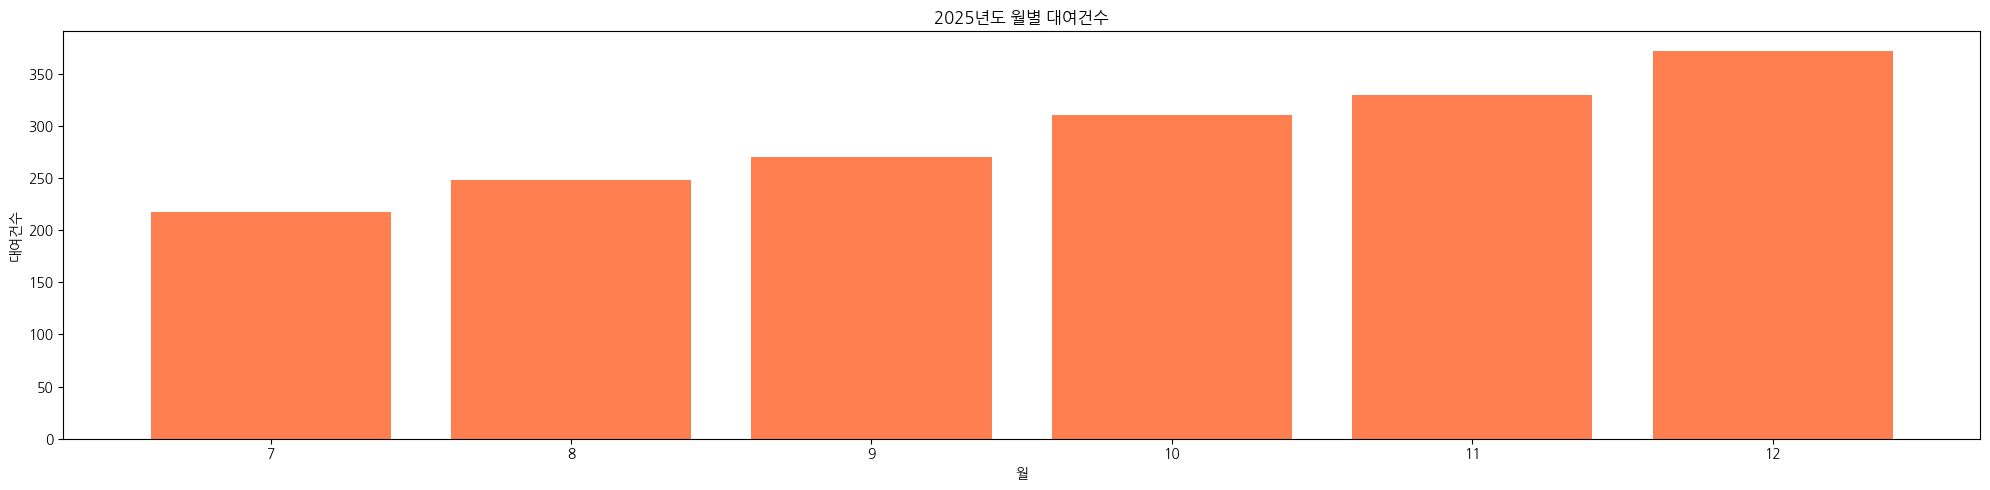

In [26]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='coral')
plt.title('2025년도 월별 대여건수')
plt.xlabel('월')
plt.ylabel('대여건수')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# df2의 대여소별 대여건수 top5